In [1]:
#important libraries 
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


In [ ]:
file_path = r"D:\BPS\dataset\IoT\iot_benign_ddos_reduced.csv"
#define target
target = "traffic_class"

In [2]:
file_path = r"D:\BPS\dataset\2025\all_attack_benign_samples\reduced_dataset.csv"

# benign and ddos 
target = "target"

In [3]:
df = pd.read_csv(file_path) 

In [4]:
print(df[target].value_counts())

target
0    136800
1     18056
Name: count, dtype: int64


In [5]:
#separatetarget and features 
X = df.drop(columns=[target])
y = df[target]

In [6]:
# keep only numeric columns
X = X.select_dtypes(include=[np.number])

In [7]:
# Train-test split - 80-20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [8]:
print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (123884, 25)
Test: (30972, 25)


In [9]:
# train model
model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    max_leaf_nodes=1000,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, max_leaf_nodes=1000, n_estimators=50,
                       n_jobs=-1, random_state=42)

In [10]:
# predictions
y_pred = model.predict(X_test)

In [12]:
# evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)

print("\nRandom Forest Results")
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Random Forest Results
Accuracy: 0.9859550561797753
Precision: 0.9993710691823899
Recall: 0.8800886181113265
F1-score: 0.9359446326019732

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     27361
           1       1.00      0.88      0.94      3611

    accuracy                           0.99     30972
   macro avg       0.99      0.94      0.96     30972
weighted avg       0.99      0.99      0.99     30972


Confusion Matrix:

[[27359     2]
 [  433  3178]]


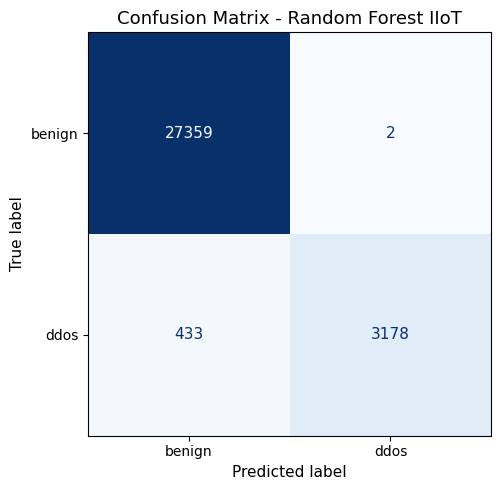

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6,5))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["benign", "ddos"],
    cmap="Blues",
    ax=ax,
    colorbar=False  
)

# fix num. size 
for text in disp.text_.ravel():
    text.set_fontsize(11)

ax.set_title("Confusion Matrix - Random Forest IIoT", fontsize=13)
ax.set_xlabel("Predicted label", fontsize=11)
ax.set_ylabel("True label", fontsize=11)
plt.tight_layout()
plt.savefig("Confusion Matrix - Random Forest IIoT", dpi=300, bbox_inches="tight")
plt.show()